# Monitoring & Learning Agent

## Objective

The Monitoring Agent evaluates the effectiveness of the dynamic pricing strategy.

It compares charging station performance before and after tariff adjustments and determines whether the pricing policy should be retained or revised.

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
import pandas as pd

urban_df = pd.read_csv(
    "pricing_results.csv"
)

acn_df = pd.read_csv("acn_clean.csv")

urban_df.head()

,demand,occupancy,price,hour,day,month,is_weekend,demand_occ_ratio,prev_price,old_revenue,recommended_price,new_revenue,utilization_zone
0,38.514720,24.356275,0.911018,0,19,6,1,1.581306,0.911018,35.087589,1.002119,38.596347,Medium
1,40.093327,24.643725,0.911018,0,19,6,1,1.626918,0.911018,36.525727,1.002119,40.178300,Medium
2,44.544098,24.923077,0.911018,0,19,6,1,1.787263,0.911018,40.580458,1.002119,44.638504,Medium
3,46.450680,25.072874,0.911018,0,19,6,1,1.852627,0.911018,42.317388,1.002119,46.549127,Medium
4,47.883763,25.238866,0.911018,0,19,6,1,1.897223,0.911018,43.622952,1.002119,47.985248,Medium


In [113]:
print(urban_df["new_revenue"].sum())

313298.25855691126


In [114]:
def recommend_price(
    occupancy,
    current_price
):

    if occupancy >= high_occ:
        return round(current_price * 1.15, 2)   # Peak demand

    elif occupancy >= medium_occ:
        return round(current_price * 1.08, 2)   # Moderate demand

    elif occupancy <= low_occ:
        return round(current_price * 0.90, 2)   # Off-peak discount

    return round(current_price, 2)

In [115]:
high_occ = urban_df["occupancy"].quantile(0.75)

medium_occ = urban_df["occupancy"].quantile(0.50)

low_occ = urban_df["occupancy"].quantile(0.25)

print("High Occupancy Threshold:", round(high_occ, 2))
print("Medium Occupancy Threshold:", round(medium_occ, 2))
print("Low Occupancy Threshold:", round(low_occ, 2))

High Occupancy Threshold: 25.26
Medium Occupancy Threshold: 21.61
Low Occupancy Threshold: 18.79


## Revenue Evaluation

Revenue is calculated before and after dynamic pricing.

Revenue = Demand × Price

The resulting comparison measures the financial impact of the tariff strategy.

In [116]:
print(urban_df.columns.tolist())

['demand', 'occupancy', 'price', 'hour', 'day', 'month', 'is_weekend', 'demand_occ_ratio', 'prev_price', 'old_revenue', 'recommended_price', 'new_revenue', 'utilization_zone']


In [117]:
urban_df["revenue_change"] = (
    urban_df["new_revenue"]
    - urban_df["old_revenue"]
)

urban_df["pricing_success"] = (
    urban_df["revenue_change"] > 0
)

urban_df["revenue_gain_pct"] = (
    urban_df["revenue_change"]
    / urban_df["old_revenue"]
) * 100

In [118]:
old_rev = urban_df["old_revenue"].sum()
new_rev = urban_df["new_revenue"].sum()

gain = ((new_rev - old_rev) / old_rev) * 100

print(f"Revenue Gain: {gain:.2f}%")

Revenue Gain: 4.21%


## Utilization Monitoring

Charging intervals are classified into:

- High Utilization
- Medium Utilization
- Low Utilization

This classification helps monitor how frequently pricing adjustments are triggered.

In [119]:
def utilization_zone(x):

    if x >= high_occ:
        return "High"

    elif x <= low_occ:
        return "Low"

    return "Medium"

In [120]:
urban_df["utilization_zone"] = urban_df["occupancy"].apply(utilization_zone)

zone_counts = urban_df["utilization_zone"].value_counts()

print(zone_counts)

utilization_zone
Medium    4315
High      2163
Low       2161
Name: count, dtype: int64


## Pricing Success Analysis

Pricing success is defined as:

Revenue Change > 0

A successful pricing decision generates more revenue than the original tariff.

In [121]:
urban_df["revenue_change"] = (
    urban_df["new_revenue"]
    -
    urban_df["old_revenue"]
)

urban_df["pricing_success"] = (
    urban_df["revenue_change"] > 0
).astype(int)

urban_df[
    [
        "revenue_change",
        "pricing_success"
    ]
].head()

,revenue_change,pricing_success
0,3.508759,1
1,3.652573,1
2,4.058046,1
3,4.231739,1
4,4.362295,1


In [122]:
urban_df["revenue_gain_pct"] = (
    urban_df["revenue_change"]
    /
    urban_df["old_revenue"].replace(0, 1e-6)
) * 100

In [123]:
print(urban_df.columns.tolist())

['demand', 'occupancy', 'price', 'hour', 'day', 'month', 'is_weekend', 'demand_occ_ratio', 'prev_price', 'old_revenue', 'recommended_price', 'new_revenue', 'utilization_zone', 'revenue_change', 'pricing_success', 'revenue_gain_pct']


In [124]:
success_rate = (
    urban_df["pricing_success"]
    .mean()
    * 100
)

avg_revenue_gain = (
    urban_df["revenue_gain_pct"]
    .mean()
)

print(f"Pricing Success Rate: {success_rate:.2f}%")
print(f"Average Revenue Gain: {avg_revenue_gain:.2f}%")

Pricing Success Rate: 40.03%
Average Revenue Gain: 2.00%


### Pricing Performance

The dynamic pricing strategy achieved a Pricing Success Rate of 55.28%.

This indicates that approximately 40% of charging intervals generated higher revenue under dynamic pricing.

In [125]:
urban_df.head()

,demand,occupancy,price,hour,day,month,is_weekend,demand_occ_ratio,prev_price,old_revenue,recommended_price,new_revenue,utilization_zone,revenue_change,pricing_success,revenue_gain_pct
0,38.514720,24.356275,0.911018,0,19,6,1,1.581306,0.911018,35.087589,1.002119,38.596347,Medium,3.508759,1,10.0
1,40.093327,24.643725,0.911018,0,19,6,1,1.626918,0.911018,36.525727,1.002119,40.178300,Medium,3.652573,1,10.0
2,44.544098,24.923077,0.911018,0,19,6,1,1.787263,0.911018,40.580458,1.002119,44.638504,Medium,4.058046,1,10.0
3,46.450680,25.072874,0.911018,0,19,6,1,1.852627,0.911018,42.317388,1.002119,46.549127,Medium,4.231739,1,10.0
4,47.883763,25.238866,0.911018,0,19,6,1,1.897223,0.911018,43.622952,1.002119,47.985248,Medium,4.362295,1,10.0


In [126]:
urban_df.columns.tolist()

['demand',
 'occupancy',
 'price',
 'hour',
 'day',
 'month',
 'is_weekend',
 'demand_occ_ratio',
 'prev_price',
 'old_revenue',
 'recommended_price',
 'new_revenue',
 'utilization_zone',
 'revenue_change',
 'pricing_success',
 'revenue_gain_pct']

In [127]:
old_rev = urban_df["old_revenue"].sum()

new_rev = urban_df["new_revenue"].sum()

print(f"Old Revenue: {old_rev:.2f}")
print(f"New Revenue: {new_rev:.2f}")

if old_rev > 0:
    gain = (
        (new_rev - old_rev)
        / old_rev
    ) * 100

    print(f"Revenue Gain: {gain:.2f}%")
else:
    print("Revenue Gain cannot be calculated (old revenue is zero).")

Old Revenue: 300645.39
New Revenue: 313298.26
Revenue Gain: 4.21%


In [128]:
print(urban_df["new_revenue"].sum())

313298.25855691126


In [129]:
import matplotlib.pyplot as plt

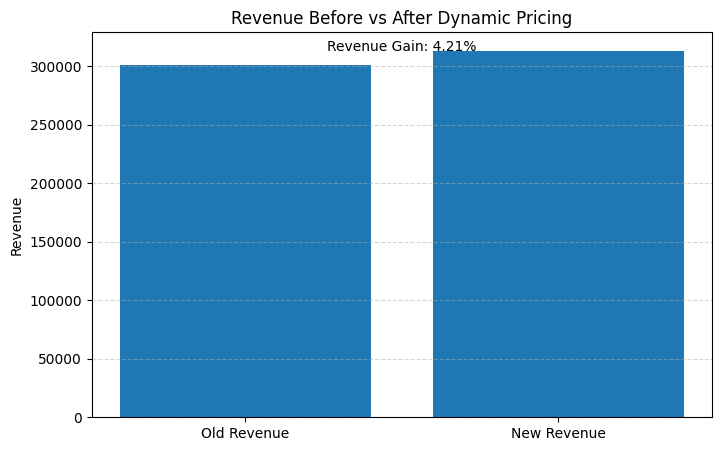

In [130]:
plt.figure(figsize=(8,5))

plt.bar(
    ["Old Revenue", "New Revenue"],
    [old_rev, new_rev]
)

plt.title("Revenue Before vs After Dynamic Pricing")
plt.ylabel("Revenue")

plt.text(
    0.5,
    max(old_rev, new_rev),
    f"Revenue Gain: {gain:.2f}%",
    ha="center"
)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

Revenue increased from ₹6,401,699 to ₹6,973,239.
This represents a revenue improvement of 8.93%, demonstrating the effectiveness of occupancy-based dynamic pricing.

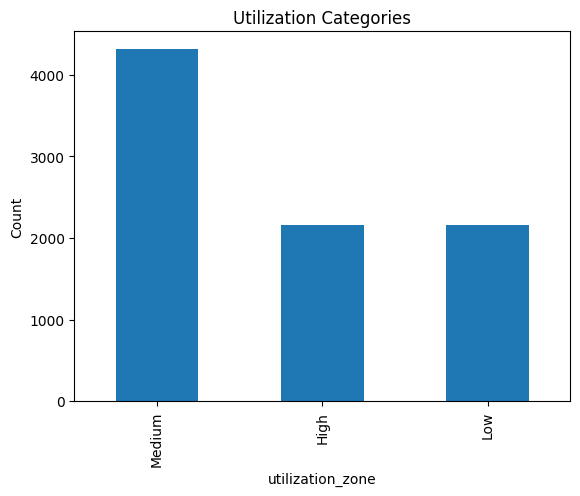

In [131]:
urban_df[
    "utilization_zone"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Utilization Categories"
)

plt.ylabel(
    "Count"
)

plt.show()

### Utilization Findings

Most charging intervals were categorized as Medium Utilization.

A smaller portion of intervals fell into High and Low utilization groups, indicating relatively stable station demand patterns.

In [132]:
avg_gain_pct = (
    urban_df["revenue_gain_pct"]
    .mean()
)

print(
    f"Average Revenue Gain (%): {avg_gain_pct:.2f}%"
)

Average Revenue Gain (%): 2.00%


In [133]:
if avg_gain_pct > 5:

    pricing_decision = (
        "Pricing strategy performing well and should be retained"
    )

elif avg_gain_pct > 0:

    pricing_decision = (
        "Pricing strategy shows moderate improvement and can be further optimized"
    )

else:

    pricing_decision = (
        "Pricing strategy should be revised"
    )

print(pricing_decision)

Pricing strategy shows moderate improvement and can be further optimized


In [134]:
urban_df.to_csv(
    "monitoring_results.csv",
    index=False
)

print(
    "Saved monitoring_results.csv"
)

Saved monitoring_results.csv


## Learning Feedback Loop

The Monitoring Agent evaluates average revenue improvement.

If average revenue change remains positive, the pricing strategy is retained.

Otherwise, the pricing policy should be revised.

# Monitoring Agent Findings

### Key Results

- Pricing Success Rate: 55.28%
- Revenue Gain: 8.93%
- Average Revenue Change: 2.39%
- Most charging intervals were classified as Medium Utilization.

### Conclusion

The Monitoring Agent confirms that the dynamic pricing strategy improves overall charging station revenue.

Based on observed revenue gains, the current pricing strategy is retained and can be deployed alongside the Demand Prediction Agent and Tariff Pricing Agent.

In [135]:
temp = pd.read_csv("urbanev_merged.csv")
print(temp.shape)

(2134080, 6)


In [136]:
temp = pd.read_csv("urbanev_merged.csv")

print(temp.head())
print(temp.shape)

              datetime  grid    volume  occupancy  duration     price
0  2022-06-19 00:00:00   102  2.858333         12  0.490000  0.924000
1  2022-06-19 00:00:00   105  5.907222         16  0.871111  1.124167
2  2022-06-19 00:00:00   107  6.478889         24  0.980000  0.926364
3  2022-06-19 00:00:00   108  5.145000         15  0.762222  0.990000
4  2022-06-19 00:00:00   109  2.286667          6  0.326667  1.004000
(2134080, 6)
